In [12]:
import pandas as pd

DATA_FILE = "../data/raw/ontario_demand_2025.csv"

df = pd.read_csv(DATA_FILE, skiprows=3)
df.head()

,Date,Hour,Market Demand,Ontario Demand
0,2025-01-01,1,17247,13887
1,2025-01-01,2,17355,13722
2,2025-01-01,3,17638,13688
3,2025-01-01,4,17065,13613
4,2025-01-01,5,17498,13593


In [13]:
df.shape

(8759, 4)

In [14]:
df.columns.tolist()

['Date', 'Hour', 'Market Demand', 'Ontario Demand']

In [17]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes

Date              datetime64[us]
Hour                       int64
Market Demand              int64
Ontario Demand             int64
dtype: object

In [ ]:
df.isna().sum()

## Understanding the Data

Each row represents one hour of electricity demand in Ontario.

- **Date**: Date of the observation
- **Hour**: Hour of the day
- **Market Demand**: Total demand supplied through the IESO-administered market
- **Ontario Demand**: Electricity demand used to supply load within Ontario

The prediction target for this project will be **Ontario Demand**

There are 8759 examples and 4 features

In [19]:
df.describe()

,Date,Hour,Market Demand,Ontario Demand
count,8759,8759.000000,8759.000000,8759.000000
mean,2025-07-02 00:10:11.576664,12.501313,18896.128097,16621.474598
min,2025-01-01 00:00:00,1.000000,13055.000000,11536.000000
25%,2025-04-02 00:00:00,7.000000,17146.500000,14866.000000
50%,2025-07-02 00:00:00,13.000000,18638.000000,16410.000000
75%,2025-10-01 00:00:00,18.500000,20464.000000,18241.500000
max,2025-12-31 00:00:00,24.000000,26714.000000,24862.000000
std,NaN,6.921886,2299.611752,2455.815560


In [22]:
hours_per_day = df.groupby("Date").size()
hours_per_day.value_counts()

24    364
23      1
Name: count, dtype: int64

In [23]:
hours_per_day[hours_per_day != 24]

Date
2025-05-01    23
dtype: int64

In [24]:
df.duplicated(subset=["Date", "Hour"]).sum()

np.int64(0)

<Axes: title={'center': 'Ontario Electricity Demand — First Week of 2025'}>

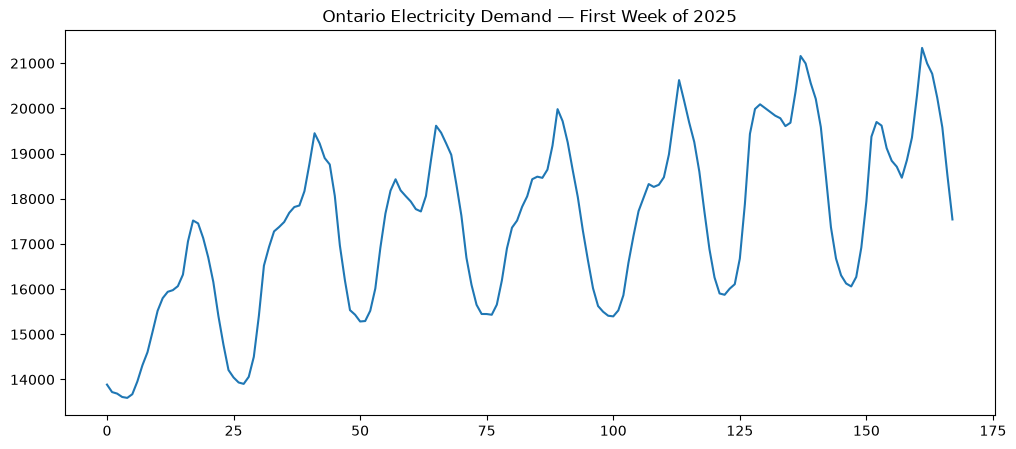

In [25]:
first_week = df[
    (df["Date"] >= "2025-01-01") &
    (df["Date"] <= "2025-01-07")
]

first_week["Ontario Demand"].plot(
    figsize=(12, 5),
    title="Ontario Electricity Demand — First Week of 2025"
)

In [26]:
may_1 = df[df["Date"] == "2025-05-01"]
may_1

,Date,Hour,Market Demand,Ontario Demand
2880,2025-05-01,2,13153,12352
2881,2025-05-01,3,13055,12249
2882,2025-05-01,4,13157,12354
2883,2025-05-01,5,14183,13195
2884,2025-05-01,6,14338,14021
2885,2025-05-01,7,15352,14965
2886,2025-05-01,8,16220,15359
2887,2025-05-01,9,16317,15317
2888,2025-05-01,10,16279,15132
2889,2025-05-01,11,16105,15043


In [27]:
expected_hours = set(range(1, 25))
actual_hours = set(may_1["Hour"])
missing_hours = expected_hours - actual_hours
missing_hours

{1}

### Data Quality Note

The dataset contains 8,759 hourly observations instead of the expected 8,760 for a 365-day year. May 1, 2025 contains 23 hourly observations, with Hour 1 missing. The missing observation is left unchanged rather than artificially creating a demand value.

In [30]:
hourly_demand = df.groupby("Hour")["Ontario Demand"].mean()
hourly_demand

Hour
1     14740.217033
2     14374.657534
3     14188.457534
4     14161.230137
5     14386.169863
6     15030.380822
7     15966.167123
8     16672.972603
9     16952.561644
10    17096.953425
11    17208.827397
12    17280.890411
13    17345.410959
14    17371.632877
15    17500.926027
16    17875.791781
17    18388.235616
18    18657.213699
19    18623.947945
20    18410.797260
21    17978.986301
22    17151.871233
23    16195.493151
24    15350.443836
Name: Ontario Demand, dtype: float64

<Axes: title={'center': 'Average Ontario Electricity Demand by Hour'}, xlabel='Hour'>

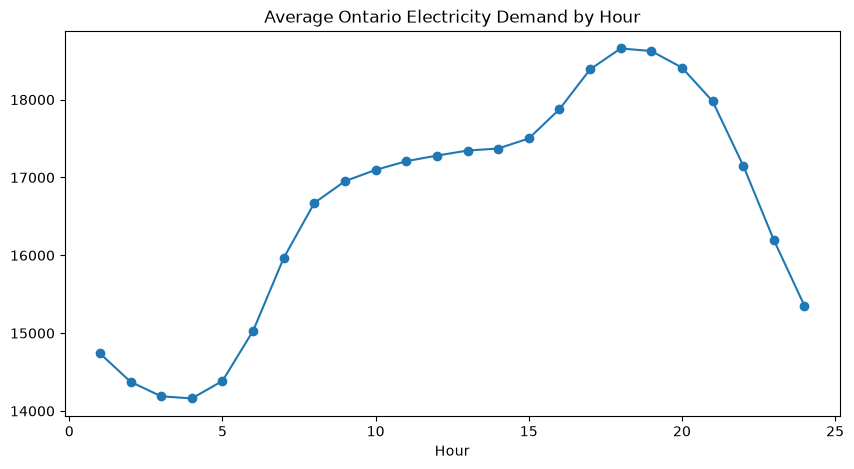

In [31]:
hourly_demand.plot(
    figsize=(10, 5),
    marker="o",
    title="Average Ontario Electricity Demand by Hour"
)